# Customer Review Sentiment Analysis

## Overview
This project performs sentiment analysis on customer reviews.

## Tasks Performed
- Loaded review data
- Removed neutral reviews
- Created sentiment labels
- Cleaned text data
- Prepared data for sentiment classification

## Libraries Used
- Pandas
- Scikit-learn
- NLP preprocessing tools

## Goal
Classify customer reviews as positive or negative.

In [1]:
import pandas as pd 

In [2]:
df = pd.read_csv("Reviews.csv")

In [3]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [15]:
df.describe()

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.000000,568454.00000,568454.000000,5.684540e+05
mean,284227.500000,1.743817,2.22881,4.183199,1.296257e+09
std,164098.679298,7.636513,8.28974,1.310436,4.804331e+07
min,1.000000,0.000000,0.00000,1.000000,9.393408e+08
25%,142114.250000,0.000000,0.00000,4.000000,1.271290e+09
50%,284227.500000,0.000000,1.00000,5.000000,1.311120e+09
75%,426340.750000,2.000000,2.00000,5.000000,1.332720e+09
max,568454.000000,866.000000,923.00000,5.000000,1.351210e+09


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [17]:
df.isnull().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

In [18]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
568449    False
568450    False
568451    False
568452    False
568453    False
Length: 568454, dtype: bool

In [4]:
df_filtered = df[df['Score'] != 3].copy()

df_filtered['Sentiment'] = df_filtered['Score'].apply(lambda x: 1 if x > 3 else 0)

print(df_filtered['Sentiment'].value_counts(normalize=True))

df_filtered[['Text', 'Sentiment']].head()

Sentiment
1    0.843981
0    0.156019
Name: proportion, dtype: float64


,Text,Sentiment
0,I have bought several of the Vitality canned d...,1
1,Product arrived labeled as Jumbo Salted Peanut...,0
2,This is a confection that has been around a fe...,1
3,If you are looking for the secret ingredient i...,0
4,Great taffy at a great price. There was a wid...,1


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    df_filtered['Text'], 
    df_filtered['Sentiment'], 
    test_size=0.2, 
    random_state=42
)


In [8]:


vectorizer = TfidfVectorizer(max_features=10000, stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = LinearSVC(class_weight='balanced', random_state=42)
model.fit(X_train_tfidf, y_train)

predictions = model.predict(X_test_tfidf)
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.64      0.90      0.75     16379
           1       0.98      0.91      0.94     88784

    accuracy                           0.91    105163
   macro avg       0.81      0.90      0.84    105163
weighted avg       0.93      0.91      0.91    105163



In [9]:
import numpy as np

feature_names = np.array(vectorizer.get_feature_names_out())
coefficients = model.coef_[0]

top_negative = np.argsort(coefficients)[:10]
top_positive = np.argsort(coefficients)[-10:]

print("Top 10 Negative Identifiers:")
for index in top_negative:
    print(f"- {feature_names[index]} ({coefficients[index]:.2f})")

print("\nTop 10 Positive Identifiers:")
for index in reversed(top_positive):
    print(f"- {feature_names[index]} ({coefficients[index]:.2f})")

Top 10 Negative Identifiers:
- worst (-4.70)
- disappointing (-4.30)
- emptor (-4.04)
- disappointment (-3.79)
- deceptive (-3.75)
- undrinkable (-3.73)
- unacceptable (-3.70)
- redeeming (-3.70)
- mediocre (-3.47)
- revolting (-3.32)

Top 10 Positive Identifiers:
- pleasantly (5.07)
- great (4.68)
- delicious (4.52)
- hooked (4.26)
- best (4.12)
- perfect (4.09)
- downside (4.04)
- deducted (3.68)
- addicting (3.60)
- highly (3.51)


In [10]:
def analyze_review(review_text):
    vectorized_text = vectorizer.transform([review_text])
    prediction = model.predict(vectorized_text)[0]
    sentiment_label = "Positive" if prediction == 1 else "Negative"
    return sentiment_label

test_reviews = [
    "The packaging arrived damaged and the taste was completely revolting.",
    "I was pleasantly surprised by how fresh and delicious these snacks were!"
]

for review in test_reviews:
    result = analyze_review(review)
    print(f"Review: \"{review}\"\nPredicted Sentiment: {result}\n")

Review: "The packaging arrived damaged and the taste was completely revolting."
Predicted Sentiment: Negative

Review: "I was pleasantly surprised by how fresh and delicious these snacks were!"
Predicted Sentiment: Positive



In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
from sklearn.metrics import confusion_matrix

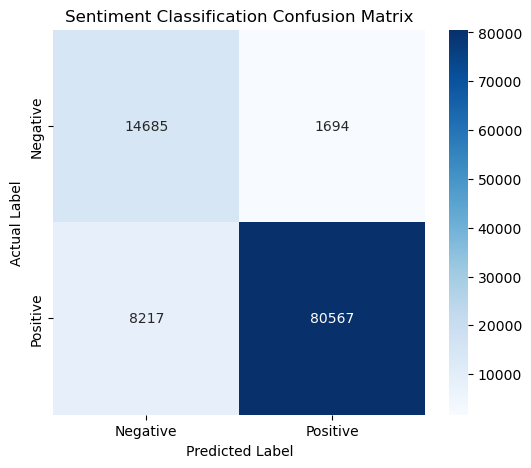

In [13]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Sentiment Classification Confusion Matrix')
plt.show()

In [14]:
import pickle

with open('sentiment_model.pkl', 'wb') as model_file:
    pickle.dump(model, model_file)

with open('tfidf_vectorizer.pkl', 'wb') as vocab_file:
    pickle.dump(vectorizer, vocab_file)

print("Project complete! Model and vectorizer saved successfully.")

Project complete! Model and vectorizer saved successfully.
